In [1]:
import pandas as pd
import numpy as np
import time

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

from reporting import *

In [2]:
# Define dtype map (force string types for mixed-type columns)
dtype_map = {
    6: str,  # Income Group ID
    7: str,  # Income Group Name
    12: str,  # Managing Sub-agency or Bureau ID
}

# Load CSV with dtype enforcement for non-integer columns, handling potential parsing issues
df_complete = pd.read_csv('downloads/us_foreign_aid_complete.csv', dtype=dtype_map, low_memory=False)

# Clean column 48 (Fiscal Year) by extracting valid 4-digit years
df_complete.iloc[:, 48] = pd.to_numeric(
    df_complete.iloc[:, 48].astype(str).str.extract(r'(\d{4})')[0],
    errors='coerce'
).astype('Int64')  # Use nullable integer type

# Handle missing or invalid values
print(f"Column 48 (Fiscal Year): {df_complete.iloc[:, 48].isna().sum()} rows had invalid year values and were set to NaN.")

# Convert other numeric columns safely (if needed, add more columns here)
numeric_columns = [48]  # Add other numeric columns if required
for col in numeric_columns:
    df_complete.iloc[:, col] = pd.to_numeric(df_complete.iloc[:, col], errors='coerce').astype('Int64')


Column 48 (Fiscal Year): 0 rows had invalid year values and were set to NaN.


In [3]:
df_complete[df_complete["Country Code"] == "MMR"]

,Country ID,Country Code,Country Name,Region ID,Region Name,Income Group ID,Income Group Name,Income Group Acronym,Managing Agency ID,Managing Agency Acronym,...,Transaction Type ID,Transaction Type Name,Fiscal Year,Transaction Date,Current Dollar Amount,Constant Dollar Amount,aid_type_id,aid_type_name,activity_budget_amount,submission_activity_id
268942,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,1,USAID,...,2,Obligations,2020,01AUG2020,75000,86804,8,Project-type interventions - not Investment Re...,30000000,60914
268943,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,1,USAID,...,2,Obligations,2021,01JUN2021,75000,83916,8,Project-type interventions - not Investment Re...,30000000,60914
268944,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,1,USAID,...,3,Disbursements,2021,01FEB2021,31126,34826,8,Project-type interventions - not Investment Re...,30000000,60914
268945,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,1,USAID,...,3,Disbursements,2021,01MAR2021,13033,14582,8,Project-type interventions - not Investment Re...,30000000,60914
268946,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,1,USAID,...,3,Disbursements,2021,01APR2021,29975,33539,8,Project-type interventions - not Investment Re...,30000000,60914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291623,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,17,TDA,...,3,Disbursements,2017,14APR2017,6993,8536,13,Technical Cooperation - Other,56700,7636
291624,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,17,TDA,...,3,Disbursements,2017,28JUL2017,13986,17073,13,Technical Cooperation - Other,56700,7636
291625,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,17,TDA,...,3,Disbursements,2017,25SEP2017,6993,8536,13,Technical Cooperation - Other,56700,7636
291626,104,MMR,Burma (Myanmar),1,East Asia and Oceania,2.0,Lower Middle Income Country,LMIC,17,TDA,...,3,Disbursements,2018,01DEC2017,21978,26246,13,Technical Cooperation - Other,56700,7636


In [4]:
df_complete["Country Name"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Azerbaijan', 'Argentina', 'Australia',
       'Austria', 'Bahamas', 'Bahrain', 'Bangladesh', 'Armenia',
       'Barbados', 'Belgium', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Belize',
       'British Indian Ocean Territory', 'Solomon Islands',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burma (Myanmar)',
       'Burundi', 'Belarus', 'Cambodia', 'Cameroon', 'Canada',
       'Cabo Verde', 'Cayman Islands', 'Central African Republic',
       'Sri Lanka', 'Chad', 'Chile', 'China (P.R.C.)', 'Taiwan',
       'Colombia', 'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)',
       'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus',
       'Czechoslovakia (former)', 'Czechia', 'Benin', 'Denmark',
       'Dominica', 'Dominican Republic', 'Ecuador', 'El Salvador',
       'Equatorial Guinea', 'Ethiopia', 'Eritrea', 'Estonia', 'Fiji',
       'Finlan

In [5]:
countries = [
    "Afghanistan", "Armenia", "Bangladesh", "Belarus", "Belgium", "Benin", "Brazil", "Bulgaria", "Burkina Faso", 
    "Burundi", "Cameroon", "Central African Republic", "Chad", "Colombia", "Comoros", "Costa Rica", "Cote d'Ivoire", "Korea, Democratic Republic of", "Congo (Kinshasa)", "Dominican Republic", "Egypt", "Eswatini", "Ethiopia", "France", "Greece", "Guatemala", "Guinea", "Haiti", "Honduras", "China (Hong Kong, S.A.R., P.R.C.)",
    "India", "Iraq", "Italy", "Israel", "Jordan", "Kazakhstan", "Kenya", "Kiribati, Republic of", "Kyrgyzstan", "Laos", "Lebanon", 
    "Liberia", "Libya", "Madagascar", "Malawi", "Malaysia", "Mali", "Mauritania", "Mexico", 
    "Mozambique", "Burma (Myanmar)", "Niger", "Nigeria", "West Bank and Gaza", "Pakistan", "Panama", "Papua New Guinea", "Philippines",
    "Poland", "Rwanda", "Senegal", "Serbia", "Sierra Leone", "Somalia", "South Africa", "South Sudan", "Spain", "Sri Lanka", "Sudan", 
    "Syria", "Taiwan", "Tajikistan", "Tanzania", "Thailand", "Tunisia", "Turkey", "Uganda", "Ukraine", "United Kingdom", "Uzbekistan", "Venezuela", "Vietnam", "Yemen", 
    "Zimbabwe"
]

In [6]:
len(countries)

84

In [7]:
# Filter by relevant countries/countries of interest
df_filtered = df_complete[df_complete["Country Name"].isin(countries) & (df_complete["Fiscal Year"] >= 2020) & (df_complete["Funding Agency Acronym"] == "USAID") & (df_complete["Transaction Type Name"] == "Obligations")]

In [8]:
df_filtered["Activity Name"] = df_filtered["Activity Name"].str.title()

C:\Users\chris\AppData\Local\Temp\ipykernel_219144\378644715.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Activity Name"] = df_filtered["Activity Name"].str.title()


In [9]:
# Check for differences/missing countries

a = list(df_filtered["Country Name"].unique())

c = list(set(countries) - set(a))

print(c)

['France', 'China (Hong Kong, S.A.R., P.R.C.)', 'United Kingdom']


In [10]:
df_filtered.head()

,Country ID,Country Code,Country Name,Region ID,Region Name,Income Group ID,Income Group Name,Income Group Acronym,Managing Agency ID,Managing Agency Acronym,...,Transaction Type ID,Transaction Type Name,Fiscal Year,Transaction Date,Current Dollar Amount,Constant Dollar Amount,aid_type_id,aid_type_name,activity_budget_amount,submission_activity_id
181,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2021,01SEP2021,800,895,17,Administrative costs not included elsewhere,.,50529
182,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2022,01MAY2022,-430,-450,17,Administrative costs not included elsewhere,.,50529
183,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2023,01APR2023,1419,1419,17,Administrative costs not included elsewhere,.,50529
184,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2024,01MAR2024,504912,491779,17,Administrative costs not included elsewhere,.,50529
195,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2022,01JAN2022,-78,-82,17,Administrative costs not included elsewhere,.,50916


In [11]:
df_filtered['Country Code'].nunique()

81

In [20]:
# df_filtered.to_csv('downloads/us_foreign_aid_processed.csv', index=False)

In [13]:
df_filtered[df_filtered['Country Name'] == "Afghanistan"]

,Country ID,Country Code,Country Name,Region ID,Region Name,Income Group ID,Income Group Name,Income Group Acronym,Managing Agency ID,Managing Agency Acronym,...,Transaction Type ID,Transaction Type Name,Fiscal Year,Transaction Date,Current Dollar Amount,Constant Dollar Amount,aid_type_id,aid_type_name,activity_budget_amount,submission_activity_id
181,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2021,01SEP2021,800,895,17,Administrative costs not included elsewhere,.,50529
182,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2022,01MAY2022,-430,-450,17,Administrative costs not included elsewhere,.,50529
183,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2023,01APR2023,1419,1419,17,Administrative costs not included elsewhere,.,50529
184,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2024,01MAR2024,504912,491779,17,Administrative costs not included elsewhere,.,50529
195,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,1,USAID,...,2,Obligations,2022,01JAN2022,-78,-82,17,Administrative costs not included elsewhere,.,50916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,2,STATE,...,2,Obligations,2021,30SEP2021,-14090,-15765,17,Administrative costs not included elsewhere,.,187
60394,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,2,STATE,...,2,Obligations,2022,30JUN2022,-1300,-1359,17,Administrative costs not included elsewhere,.,187
60395,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,2,STATE,...,2,Obligations,2023,30SEP2023,-897568,-897568,17,Administrative costs not included elsewhere,.,187
63981,4,AFG,Afghanistan,4,South and Central Asia,1.0,Low Income Country,LIC,2,STATE,...,2,Obligations,2021,24SEP2021,5925925,6630409,8,Project-type interventions - not Investment Re...,.,1709


In [14]:
# Reporting on a country level (e.g., "Afghanistan")
country = "Afghanistan"

print("Top 10 Activities by Current Funding (2024):")
activities_df = get_top_activities_by_funding(df_filtered, country, year=2024, top_n=10)
print(activities_df)

print("\nTop 10 Partners by Current Funding (2024):")
partners_df = get_top_partners_by_funding(df_filtered, country, year=2024, top_n=10)
print(partners_df)

print("\nTop 10 Sectors by Current Funding (2024):")
sectors_df = get_top_sectors_by_funding(df_filtered, country, year=2024, top_n=10)
print(sectors_df)

print("\nFunding per Category (2024):")
category_df = get_funding_per_category(df_filtered, country, year=2024)
print(category_df)


Top 10 Activities by Current Funding (2024):
                                        Activity Name  Current Dollar Amount
15                            Humanitarian Assistance              444305271
36  Usaid Redacted This Field In Accordance With T...              133192396
8                   Emergency Humanitarian Assistance               61500000
35                            Urban Health Initiative               26069793
7                     Emergency Food Assistance Grant               14292479
23  National Health Technical Assistance Program (...               13603231
6                           Emergency Food Assistance                7500000
4                                 Civic Participation                6500010
22         Local Health Systems Sustainability (Lhss)                5000000
26                         Polio Immunization Funding                3000000

Top 10 Partners by Current Funding (2024):
                            Implementing Partner Name  Current D

In [19]:
# Reporting on a country level (e.g., "Afghanistan")
country = "Afghanistan"

print("Top 10 Activities by Current Funding (2025):")
activities_df = get_top_activities_by_funding(df_filtered, country, year=2025, top_n=10)
print(activities_df)

print("\nTop 10 Partners by Current Funding (2025):")
partners_df = get_top_partners_by_funding(df_filtered, country, year=2025, top_n=10)
print(partners_df)

print("\nTop 10 Sectors by Current Funding (2025):")
sectors_df = get_top_sectors_by_funding(df_filtered, country, year=2025, top_n=10)
print(sectors_df)

print("\nFunding per Category (2025):")
category_df = get_funding_per_category(df_filtered, country, year=2025)
print(category_df)

Top 10 Activities by Current Funding (2025):
                                       Activity Name  Current Dollar Amount
4  National Health Technical Assistance Program (...                4460326
0                                    A&A Specialists                 526290
1                       Administrative Costs (Icass)                   -568
2  Gh-Tams - The Global Health Technical Assistan...                 -14377
3                            Humanitarian Assistance                 -20212
5  Usaid Redacted This Field In Accordance With T...               -2217987

Top 10 Partners by Current Funding (2025):
                            Implementing Partner Name  Current Dollar Amount
4                        NGO - United States Redacted                4440114
7   U.S. Government - U.S. Agency for Internationa...                1336112
2                 Enterprise - United States Redacted                 255820
9                   Unspecified Vendors - Afghanistan                 1

C:\Users\chris\Documents\01Projects\MSF\msf-toolbox\src\msftoolbox\usaid\reporting.py:149: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


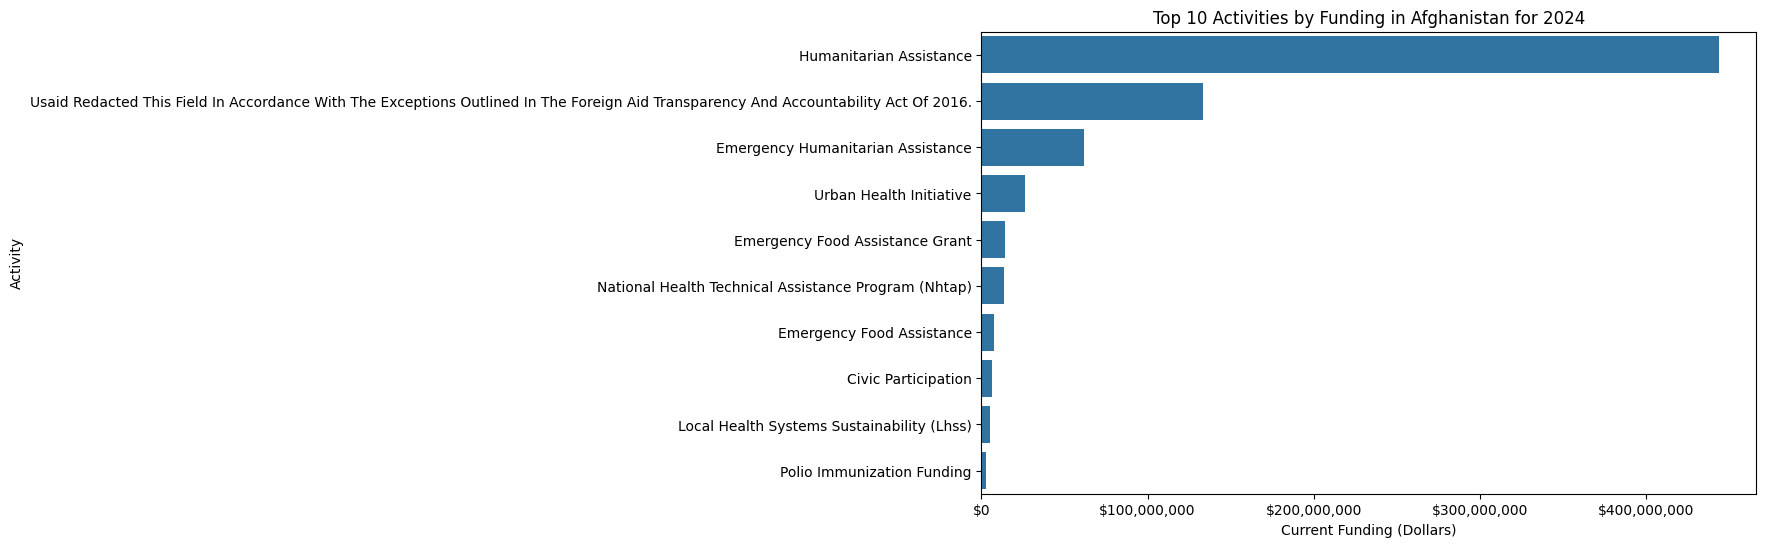

In [15]:
# ---------------------------------
# Optional: Generate plots for quick visual summaries
# ---------------------------------

# Plotting the top activities by funding
plot_top_activities_by_funding(df_filtered, country, year=2024, top_n=10)

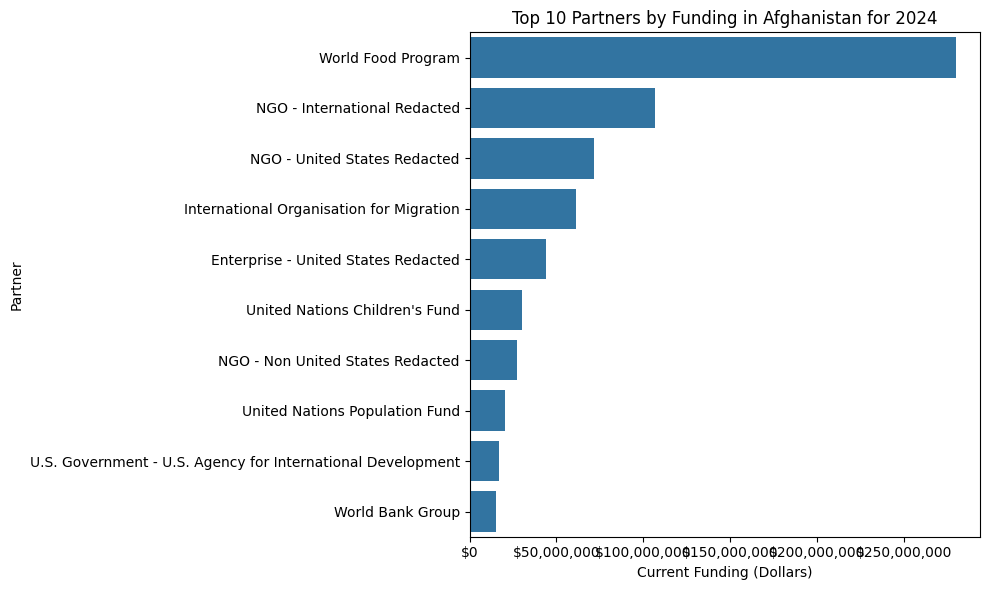

In [16]:
# Plotting the top partners by funding
plot_top_partners_by_funding(df_filtered, country, year=2024, top_n=10)

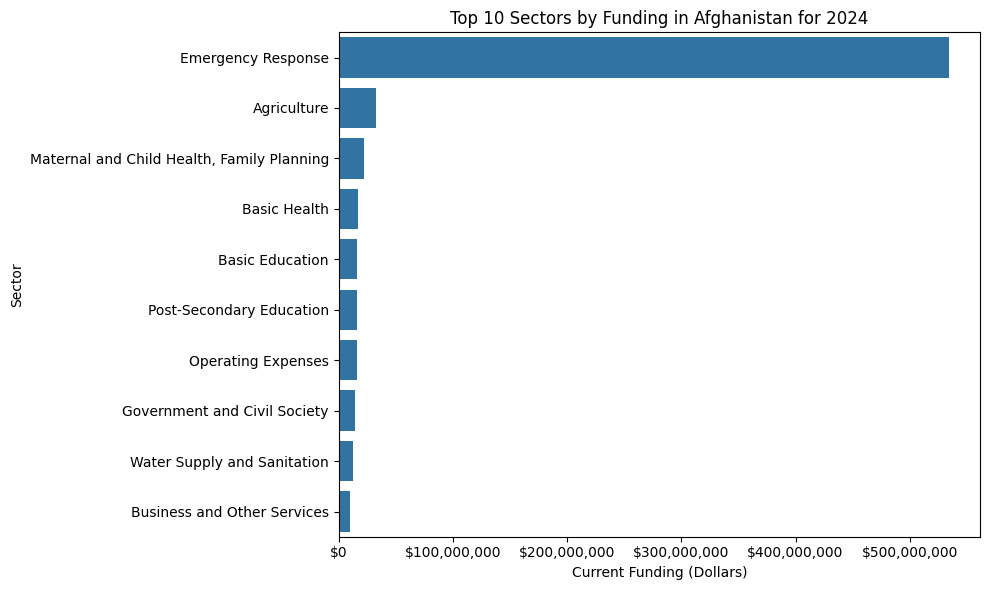

In [17]:
# Plotting the top sectors by funding
plot_top_sectors_by_funding(df_filtered, country, year=2024, top_n=10)

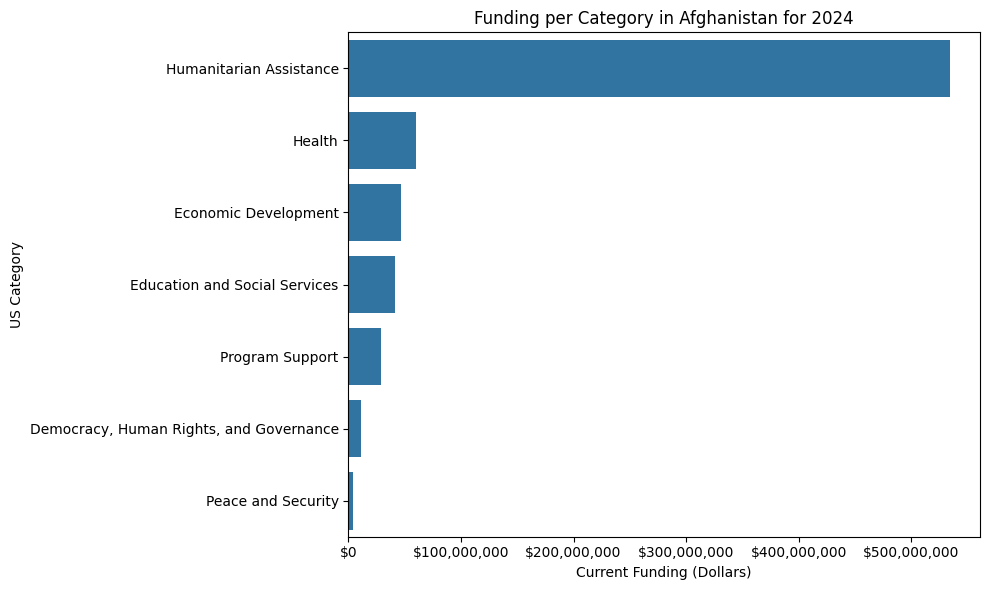

In [18]:
# Plotting total funding per category
plot_funding_per_category(df_filtered, country, year=2024)